## Step 1 : Let's Record the voice


## Step 2 : let's upload the audio

## Step 3 : Load the file

In [ ]:
import librosa

y, sr = librosa.load("hello.wav", sr=None)

This isn't speech anymore. It is just thousands of numbers.

In [ ]:
print("Sampling Rate:", sr)
print("Shape:", y.shape)
print(y[:20])

Sampling Rate: 48000
Shape: (103424,)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## Step 4 : Show Waveform

This is my voice.The computer sees this. <br>


*   Not English.
*   Not Urdu

Just a waveform.

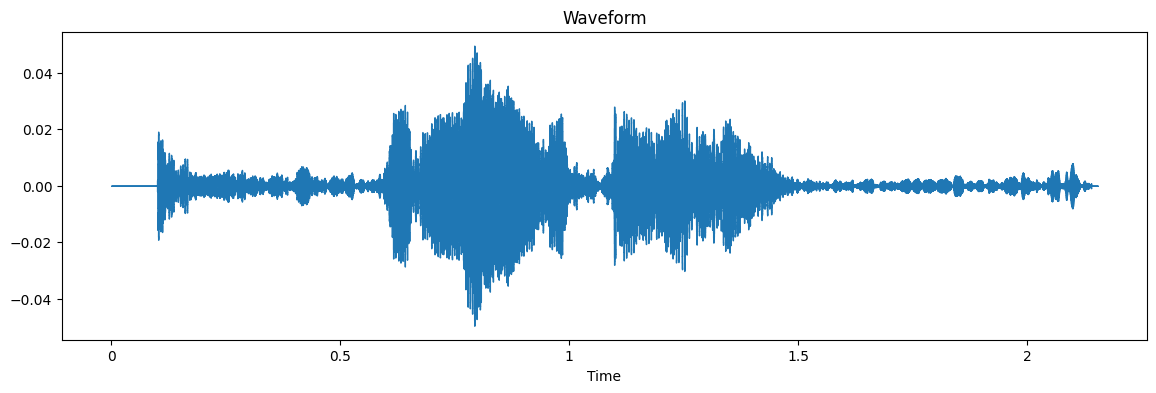

In [ ]:
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform")
plt.show()

## Step 5 : Zoom in

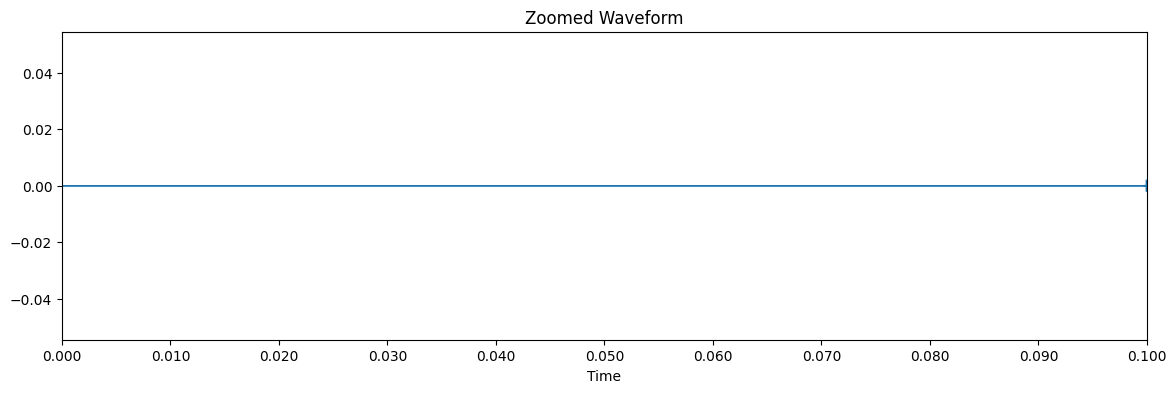

In [ ]:
plt.figure(figsize=(14,4))

librosa.display.waveshow(y, sr=sr)

plt.xlim(0.,0.1)

plt.title("Zoomed Waveform")

plt.show()

## Step 6 Show numbers

In [ ]:
print(y[:5000])

[ 0.          0.          0.         ... -0.00061035 -0.00088501
 -0.00125122]


In [ ]:
import pandas as pd
pd.DataFrame(y[500:1000], columns=["Amplitude"])

,Amplitude
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
495,0.0
496,0.0
497,0.0
498,0.0


## Step 7 : Extract MFCC

In [ ]:
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

print(mfcc.shape)

(13, 203)


## Step 8 : Display MFCC

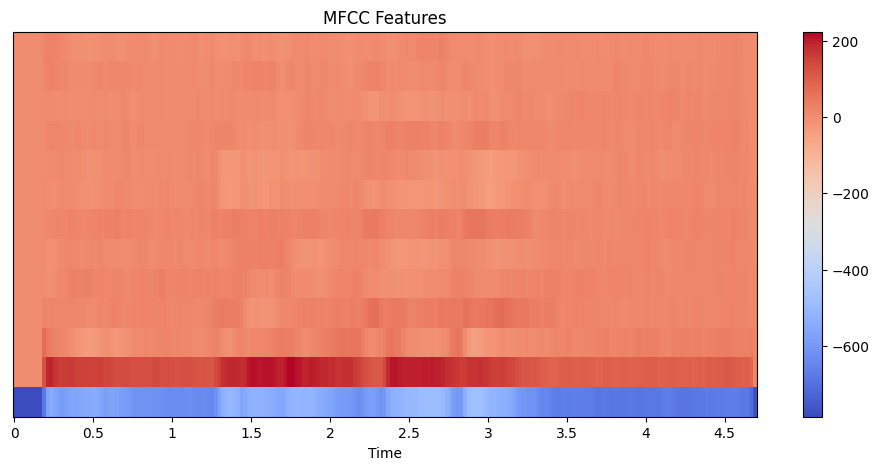

In [ ]:
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title("MFCC Features")

plt.show()

## Step 9 : MFCC Into Table

In [ ]:
import pandas as pd

mfcc_df = pd.DataFrame(mfcc.T)

mfcc_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-785.326294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-785.326294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-785.326294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-785.326294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-785.326294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 10 : Spectogram

In [ ]:
import numpy as np
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

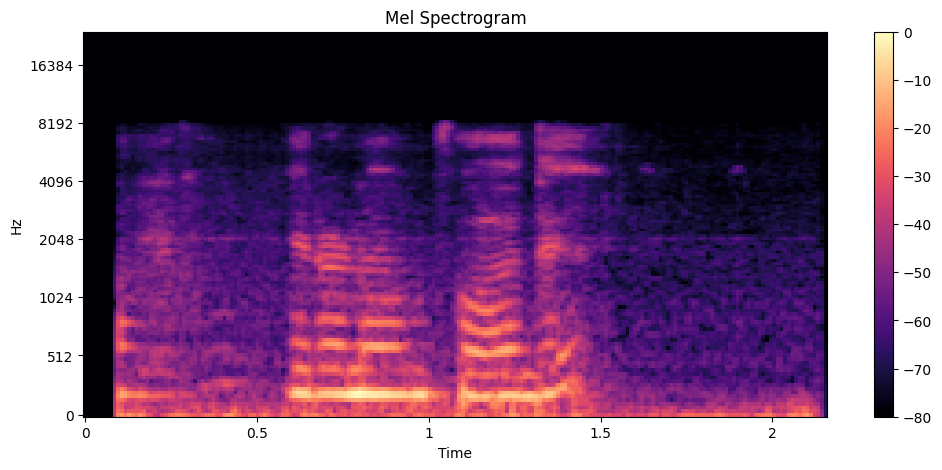

In [ ]:
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.show()

## Step 11 : Prediction


In [ ]:
!pip install transformers

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "audio-classification"
)

classifier("hello.wav")